In [1]:
import pandas as pd

#load the data into a dataframe, we only need two columns for this
df = pd.read_csv(
    "c:\\Users\\dalla\\Downloads\\f2608533-be6e-4ac5-9419-a03ad903df49.csv",
    usecols=["incident_date", "time_to_force"],
    parse_dates=["incident_date"]
)
#drop the instances where force was not used. 
force_df = df[df['time_to_force'].notna()]

#separate the data by week to create groups
weekly_force = force_df.groupby(
    pd.Grouper(key='incident_date', freq='W')
).size()

weekly_force.head()


incident_date
2025-01-05    1
2025-01-12    0
2025-01-19    0
2025-01-26    1
2025-02-02    2
Freq: W-SUN, dtype: int64

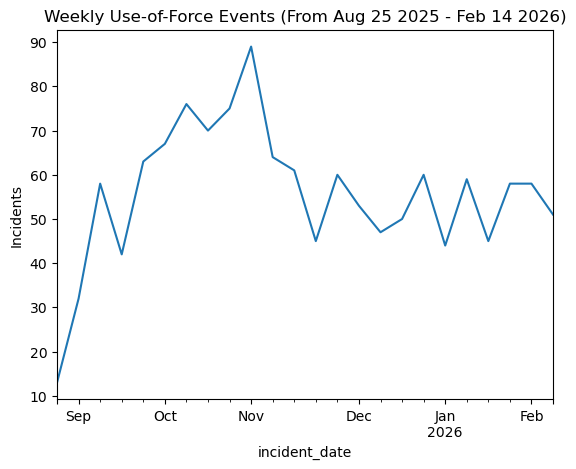

In [2]:
#filter the values to only contain points where we got consistent data. 
filtered = weekly_force.loc['2025-08-25': '2026-02-14']
import matplotlib.pyplot as plt

#plot the weekly rate of force. 
filtered.plot()
plt.title("Weekly Use-of-Force Events (From Aug 25 2025 - Feb 14 2026)")
plt.ylabel("Incidents")
plt.show()

In [3]:
#use ADF test to find if time series is stationarity
from statsmodels.tsa.stattools import adfuller

result = adfuller(filtered)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.9219290409927807
p-value: 0.0018792594941384837


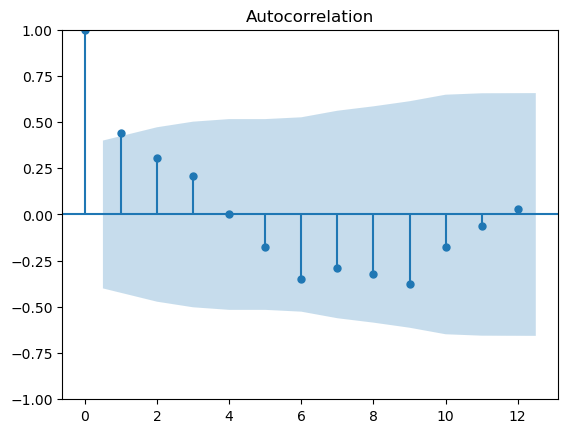

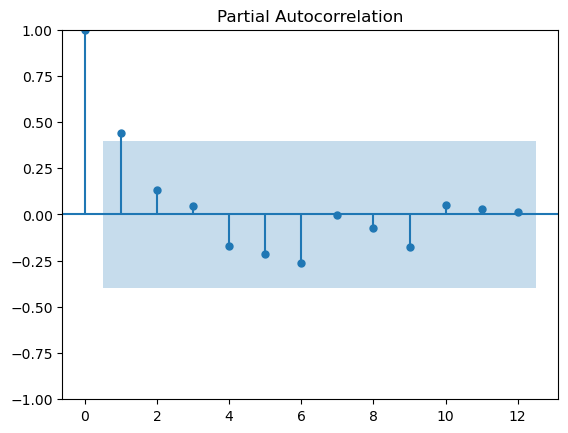

In [4]:



from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


plot_acf(filtered)
plot_pacf(filtered)
plt.show()



In [5]:
#fit the arima model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(filtered, order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -94.906
Date:                Fri, 15 May 2026   AIC                            197.812
Time:                        13:59:23   BIC                            202.525
Sample:                    08-31-2025   HQIC                           199.063
                         - 02-08-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.3317      7.161      7.169      0.000      37.297      65.366
ar.L1          0.7867      0.167      4.715      0.000       0.460       1.114
ma.L1         -0.2240      0.377     -0.594      0.5

In [6]:
#forecast for future weeks
forecast = model_fit.forecast(steps=5)

print(forecast)

2026-02-15    52.143027
2026-02-22    51.969968
2026-03-01    51.833823
2026-03-08    51.726718
2026-03-15    51.642458
Freq: W-SUN, Name: predicted_mean, dtype: float64


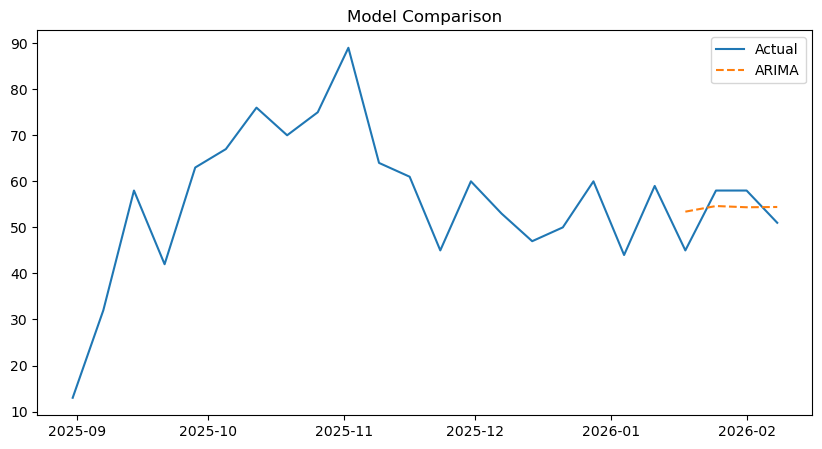

In [47]:
plt.figure(figsize=(10,5))

observed = weekly_force.loc['2025-08-25':]

plt.plot(observed.index[:-5], observed[:-5], label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA", linestyle="--")

plt.legend()
plt.title("Model Comparison")
plt.show()

In [7]:
pip install xgboost scikit-learn

In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [9]:
df = filtered.to_frame(name='y')

# create lag features
for lag in range(1, 5):
    df[f'lag_{lag}'] = df['y'].shift(lag)

df = df.dropna()

In [10]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

X_train = train.drop(columns=['y'])
y_train = train['y']

X_test = test.drop(columns=['y'])
y_test = test['y']

In [11]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5.362248172638224


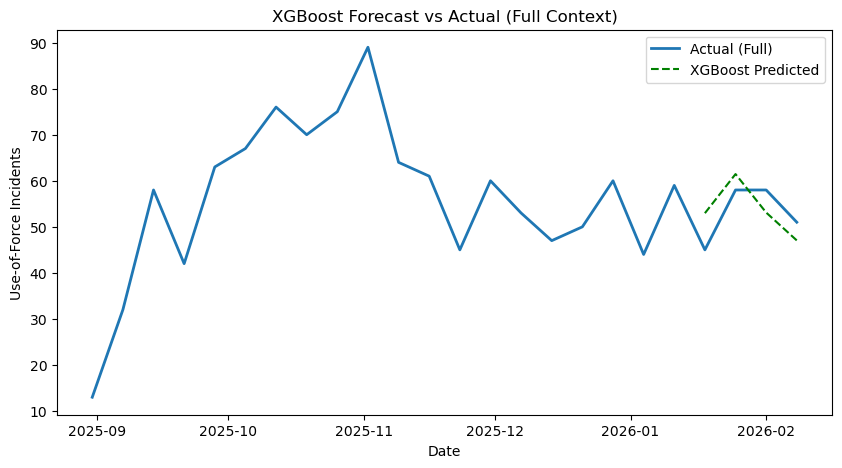

In [31]:
plt.figure(figsize=(10,5))

# full history
plt.plot(observed.index[:-5], observed[:-5], label="Actual (Full)", linewidth=2)

# test predictions
plt.plot(y_test.index, y_pred, label="XGBoost Predicted", linestyle="--", color = "green")


plt.legend()
plt.title("XGBoost Forecast vs Actual (Full Context)")
plt.xlabel("Date")
plt.ylabel("Use-of-Force Incidents")
plt.show()

In [33]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]
xgb_pred = y_pred

In [35]:
arima_model = ARIMA(train['y'], order=(1,1,1))
arima_fit = arima_model.fit()

# forecast same number of steps as test set
arima_pred = arima_fit.forecast(steps=len(test))

In [37]:
if(len(xgb_pred) == len(arima_pred) == len(test)):
    arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_pred))
    xgb_rmse = np.sqrt(mean_squared_error(test['y'], xgb_pred))
    print("if statement passed")

if statement passed


In [39]:
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_pred))
xgb_rmse = np.sqrt(mean_squared_error(test['y'], xgb_pred))

In [41]:
print("ARIMA RMSE:", arima_rmse)
print("XGBoost RMSE:", xgb_rmse)

mean_val = test['y'].mean()

print("ARIMA % Error:", arima_rmse / mean_val)
print("XGB % Error:", xgb_rmse / mean_val)

ARIMA RMSE: 5.173423701990661
XGBoost RMSE: 5.362248172638224
ARIMA % Error: 0.09761176796208794
XGB % Error: 0.10117449382336272


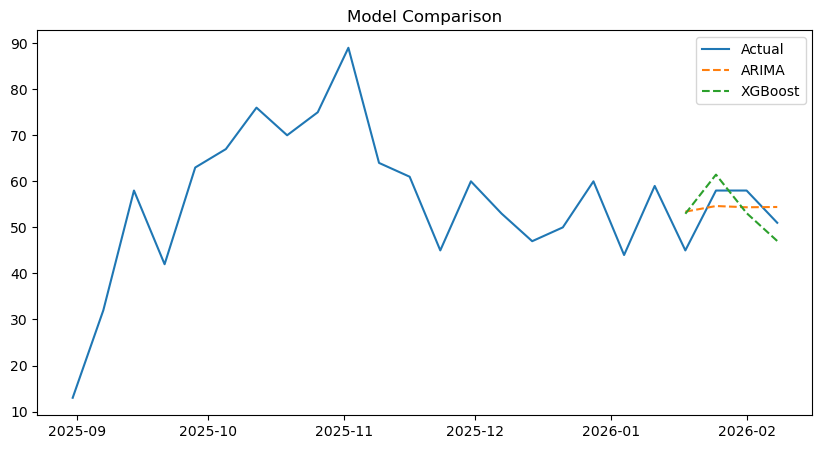

In [43]:
plt.figure(figsize=(10,5))

plt.plot(observed.index[:-5], observed[:-5], label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA", linestyle="--")
plt.plot(test.index, xgb_pred, label="XGBoost",  linestyle="--")

plt.legend()
plt.title("Model Comparison")
plt.show()